In [1]:
# Cell 1
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import pandas as pd, matplotlib.pyplot as plt

rfm = pd.read_csv('../data/rfm.csv')
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])

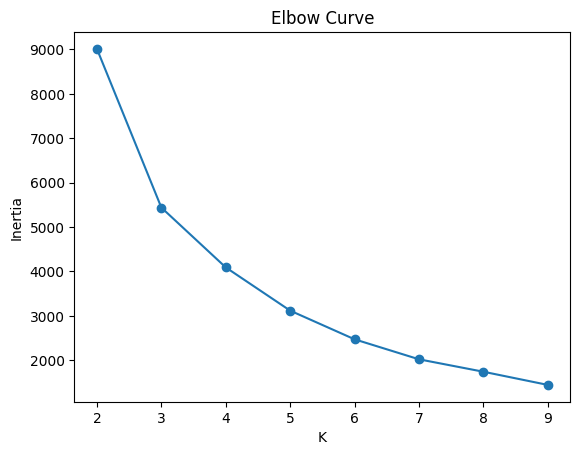

In [2]:
# Cell 2 – Elbow method to pick K
inertias = []
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)

plt.plot(range(2,10), inertias, marker='o')
plt.xlabel('K'); plt.ylabel('Inertia'); plt.title('Elbow Curve')
plt.show()

In [3]:
# Cell 3 – Fit KMeans with K=4 (adjust after elbow)
km = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = km.fit_predict(rfm_scaled)
print(rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean())

            Recency  Frequency       Monetary
Cluster                                      
0         43.702685   3.682711    1359.049284
1        248.075914   1.552015     480.617480
2          7.384615  82.538462  127338.313846
3         15.500000  22.333333   12709.090490


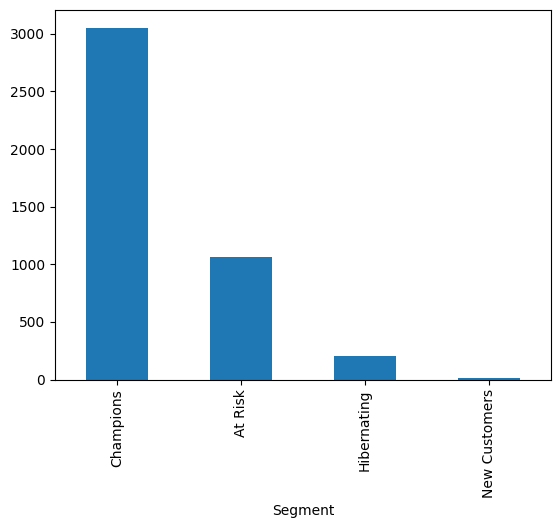

In [4]:
# Cell 4 – Label clusters with business names
labels = {0: 'Champions', 1: 'At Risk', 2: 'New Customers', 3: 'Hibernating'}
# adjust mapping after you see the means above
rfm['Segment'] = rfm['Cluster'].map(labels)
rfm.to_csv('../data/rfm_segmented.csv', index=False)
rfm['Segment'].value_counts().plot(kind='bar')
plt.show()